# XGBoost Traffic Forecasting Model

This notebook develops and evaluates an XGBoost regression model for short-term airport traffic forecasting. The model uses traffic-related and temporal features to predict traffic for 1-hour, 2-hour, and 3-hour ahead forecasting horizons.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Load the Traffic Dataset

In [2]:
df = pd.read_csv("model_ready_traffic.csv")

# Make sure data is sorted chronologically
df["hour"] = pd.to_datetime(df["hour"])
df = df.sort_values("hour").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["hour"].min(), "to", df["hour"].max())

Shape: (4857, 31)
Date range: 2025-03-21 21:00:00+00:00 to 2025-10-10 05:00:00+00:00


## 3. Select Features and Targets

The model uses traffic activity, temporal, lag, and rolling-statistics features as inputs. The three target variables represent the forecasting horizons used in this study: 1-hour, 2-hour, and 3-hour ahead traffic forecasts.

In [3]:
feature_cols = [
    'flight_count',
    'arrival',
    'departure',
    'terminal_1_count',
    'terminal_2_count',
    'terminal_3_count',
    'terminal_4_count',
    'terminal_5_count',
    'unique_airlines',
    'unique_aircraft_models',
    'unique_routes',
    'hour_of_day',
    'day_of_week',
    'is_weekend',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'lag_1h',
    'lag_2h',
    'lag_3h',
    'lag_24h',
    'lag_48h',
    'lag_168h',
    'rolling_mean_3h',
    'rolling_mean_24h',
    'rolling_std_24h'
]

target_cols = [
    'target_t1',
    'target_t2',
    'target_t3'
]

X = df[feature_cols]
y = df[target_cols]

## 4. Chronological Train, Validation, and Test Split

Because the data represents a time series, the observations are split chronologically without shuffling. The data is divided into 70% training, 15% validation, and 15% test sets.

In [4]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end].copy()
X_val   = X.iloc[train_end:val_end].copy()
X_test  = X.iloc[val_end:].copy()

y_train = y.iloc[:train_end].copy()
y_val   = y.iloc[train_end:val_end].copy()
y_test  = y.iloc[val_end:].copy()

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (3399, 27)
Validation: (729, 27)
Test: (729, 27)


In [5]:
print("\nTrain period:")
print(df["hour"].iloc[0], "to", df["hour"].iloc[train_end - 1])

print("\nValidation period:")
print(df["hour"].iloc[train_end], "to", df["hour"].iloc[val_end - 1])

print("\nTest period:")
print(df["hour"].iloc[val_end], "to", df["hour"].iloc[-1])


Train period:
2025-03-21 21:00:00+00:00 to 2025-08-10 11:00:00+00:00

Validation period:
2025-08-10 12:00:00+00:00 to 2025-09-09 20:00:00+00:00

Test period:
2025-09-09 21:00:00+00:00 to 2025-10-10 05:00:00+00:00


## 5. Train the XGBoost Models

A separate XGBoost regression model is trained for each forecasting horizon. The validation set is used to monitor model performance during development, while the test set is reserved for final evaluation.

In [6]:
from xgboost import XGBRegressor

best_params = {
    "target_t1": {
        "n_estimators": 800,
        "learning_rate": 0.03,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 2,
        "gamma": 0.05
    },

    "target_t2": {
        "n_estimators": 700,
        "learning_rate": 0.04,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.9,
        "min_child_weight": 1,
        "gamma": 0
    },

    "target_t3": {
        "n_estimators": 700,
        "learning_rate": 0.04,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.9,
        "min_child_weight": 1,
        "gamma": 0
    }
}

In [7]:
models = {}
predictions = {}

for target in target_cols:

    params = best_params[target]

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        **params
    )

    # Train + Validation
    X_train_full = pd.concat([X_train, X_val])
    y_train_full = pd.concat([y_train[target], y_val[target]])

    model.fit(
        X_train_full,
        y_train_full,
        verbose=False
    )

    models[target] = model

    predictions[target] = model.predict(X_test)

print("Optimized XGBoost models trained successfully.")

Optimized XGBoost models trained successfully.


## 6. Evaluate Model Performance

The XGBoost models are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and symmetric Mean Absolute Percentage Error (sMAPE). These metrics are calculated separately for each forecasting horizon.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def smape(y_true, y_pred):

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2

    return np.mean(
        np.where(
            denominator == 0,
            0,
            np.abs(y_true - y_pred) / denominator
        )
    ) * 100


results = []

for target in target_cols:

    y_true = y_test[target].values
    y_pred = predictions[target]

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    smape_value = smape(y_true, y_pred)

    results.append({
        "Horizon": target,
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE (%)": smape_value
    })

results_df = pd.DataFrame(results)

results_df

,Horizon,MAE,RMSE,sMAPE (%)
0,target_t1,1.737970,2.376841,6.217222
1,target_t2,1.788126,2.714029,6.506256
2,target_t3,1.829639,2.788015,6.659646


The XGBoost model is evaluated across all three forecasting horizons. The results show how prediction error changes as the forecasting horizon increases.

## 7. Calculate sMAPE

sMAPE is included as a percentage-based error metric to complement MAE and RMSE. It provides a normalized measure of the difference between actual and predicted traffic values.

In [9]:
def smape(y_true, y_pred):

    denominator = (
        np.abs(y_true) +
        np.abs(y_pred)
    ) / 2

    return np.mean(
        np.where(
            denominator == 0,
            0,
            np.abs(y_true - y_pred) / denominator
        )
    ) * 100

In [10]:
for target in target_cols:

    y_true = y_test[target].values
    y_pred = predictions[target]

    results_df.loc[
        results_df["Horizon"] == target,
        "sMAPE (%)"
    ] = smape(
        y_true,
        y_pred
    )

results_df

,Horizon,MAE,RMSE,sMAPE (%)
0,target_t1,1.737970,2.376841,6.217222
1,target_t2,1.788126,2.714029,6.506256
2,target_t3,1.829639,2.788015,6.659646


## 8. Actual vs. Predicted Traffic

The following plot compares actual traffic with XGBoost predictions for the 1-hour-ahead forecasting horizon over the first 200 observations of the test set.

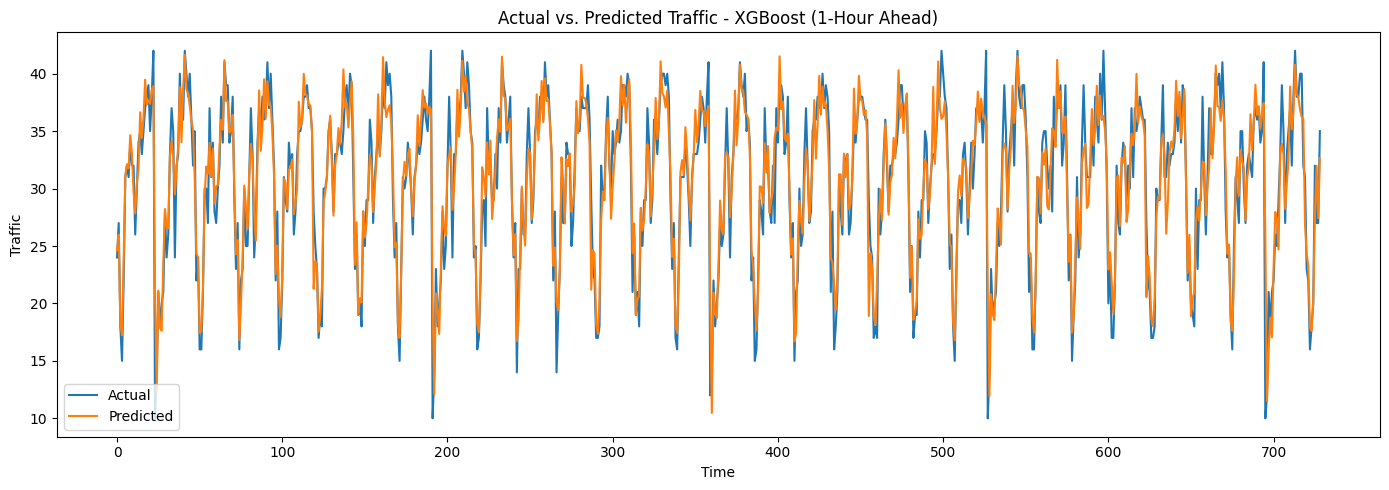

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    y_test["target_t1"].values,
    label="Actual"
)

plt.plot(
    predictions["target_t1"],
    label="Predicted"
)

plt.xlabel("Time")
plt.ylabel("Traffic")
plt.title("Actual vs. Predicted Traffic - XGBoost (1-Hour Ahead)")
plt.legend()
plt.tight_layout()
plt.show()

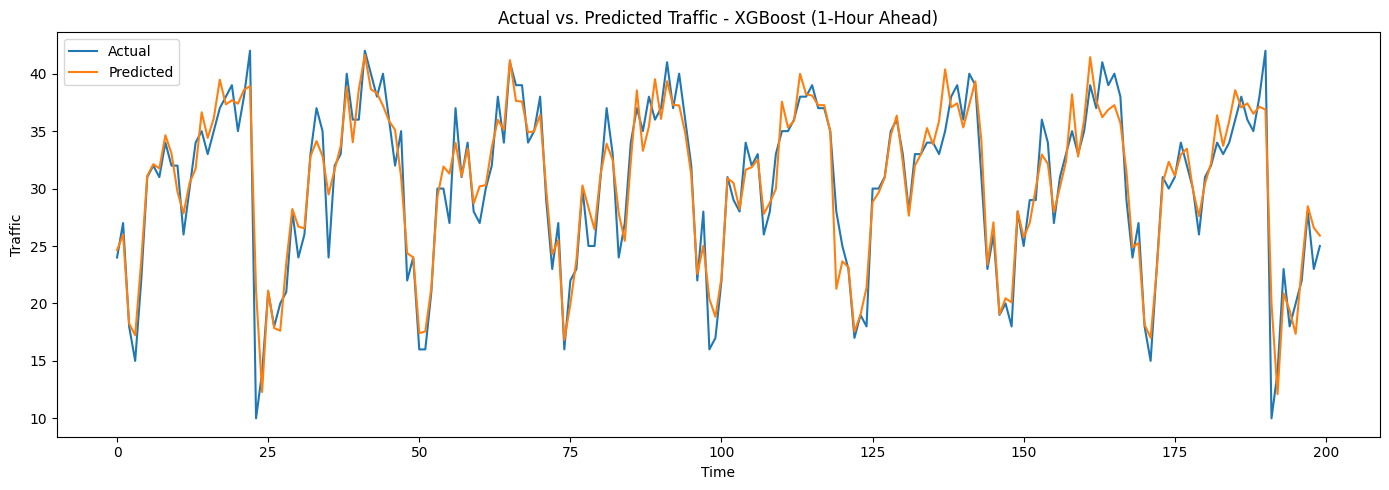

In [12]:
n_points = 200

plt.figure(figsize=(14, 5))

plt.plot(
    y_test["target_t1"].values[:n_points],
    label="Actual"
)

plt.plot(
    predictions["target_t1"][:n_points],
    label="Predicted"
)

plt.xlabel("Time")
plt.ylabel("Traffic")
plt.title("Actual vs. Predicted Traffic - XGBoost (1-Hour Ahead)")
plt.legend()
plt.tight_layout()
plt.show()

The plot compares the actual traffic values with the XGBoost predictions for the 1-hour-ahead forecasting horizon on the test set.

## 9. XGBoost Feature Importance

Feature importance is examined to identify which input variables contribute most to the XGBoost predictions for the 1-hour-ahead forecasting horizon.

In [13]:
importance = pd.Series(
    models["target_t1"].feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

importance.head(15)

,0
hour_of_day,0.318536
hour_sin,0.259339
terminal_5_count,0.107601
hour_cos,0.068998
flight_count,0.061074
arrival,0.024186
day_of_week,0.017190
terminal_2_count,0.010753
rolling_mean_3h,0.010727
rolling_mean_24h,0.010039


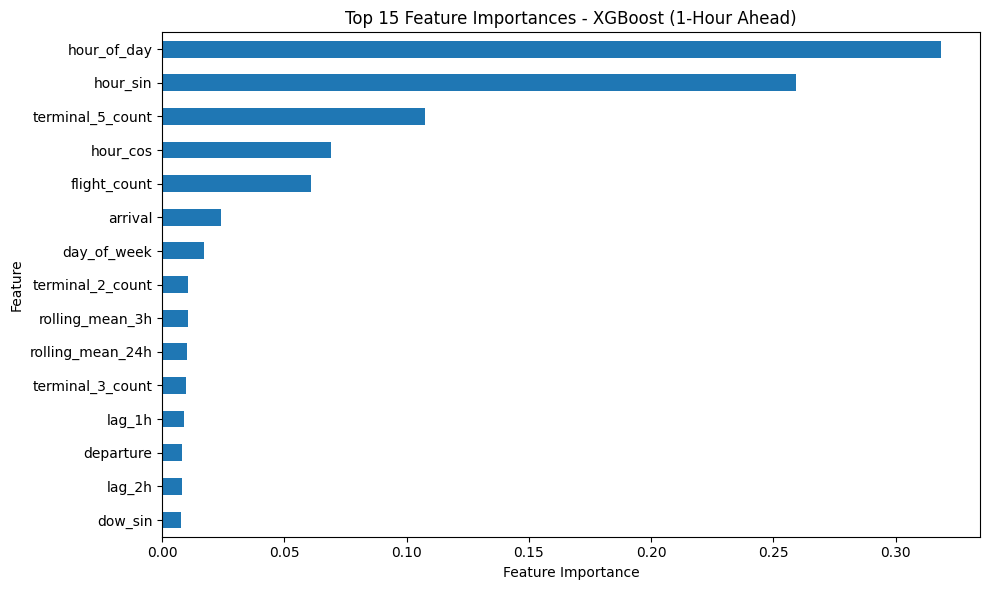

In [14]:
plt.figure(figsize=(10, 6))

importance.head(15).sort_values().plot(
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Feature Importances - "
    "XGBoost (1-Hour Ahead)"
)

plt.tight_layout()
plt.show()

## 10. XGBoost Results Summary

The XGBoost model is evaluated across the three forecasting horizons using MAE, RMSE, and sMAPE. The results provide the traffic-only baseline for comparison with the LSTM and GRU forecasting models.

In [15]:
results_df.round(3)

,Horizon,MAE,RMSE,sMAPE (%)
0,target_t1,1.738,2.377,6.217
1,target_t2,1.788,2.714,6.506
2,target_t3,1.830,2.788,6.660


## 11. Summary

XGBoost provides a traffic-only baseline for short-term airport traffic forecasting. Separate models are trained for the 1-hour, 2-hour, and 3-hour ahead forecasting horizons using traffic activity, temporal, lag, and rolling-statistics features. The final test results are reported using MAE, RMSE, and sMAPE and are used for comparison with the other forecasting models.